In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## GROUP 13 Lab 04

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196

#PROBLEM 1. Limitations of the Euler’s method

## Numerical Solution of the Airy Equation
To demonstrate the limitations of Euler’s method by solving the **Airy equation**

$$
\frac{d^2 x}{dt^2} = t\,x(t)
$$

numerically using:
- Euler’s method
- A more accurate in-built solver like radau


## Rewriting as a First-Order System

The given equation is a **second-order ODE**:

$$
\frac{d^2 x}{dt^2} = t\,x
$$

We define:

$$
x_1 = x
$$
$$
x_2 = \frac{dx}{dt}
$$

Then the system becomes:

$$
\frac{dx_1}{dt} = x_2
$$
$$
\frac{dx_2}{dt} = t\,x_1
$$

This system will be solved numerically susing Euler.




## Initial Conditions and Time Domain

We integrate the system over:

- Time interval:  
  $$
  t \in [-30,\, 2]
  $$

- Initial conditions at  t = -30 :

$$
x(-30) = 0.01, \quad \frac{dx}{dt}(-30) = 0
$$

These small initial values help reveal numerical instability in Euler’s method.


In [ ]:
def airy_system(t, y):
    return np.array([
        y[1],
        t * y[0]
    ], dtype=float)


In [ ]:
t0, t1 = -30, 2
y0 = np.array([0.01, 0.0])

ns = [1000,3000,5000,10000]
euler_solutions = {}

for n in ns:
    t = np.linspace(t0, t1, n)
    y = euler(airy_system, y0, t)
    euler_solutions[n] = (t, y[:, 0])


## Accurate Solution using solve_ivp

The **Radau method** is an implicit, high-order solver designed for:
- stiff equations
- rapidly growing or decaying solutions

It provides a highly accurate reference solution.


In [ ]:
def airy_system(t, y):
    return [y[1], t * y[0]]

t_span = (-30, 2)
y0 = [0.01, 0.0]

sol_radau = solve_ivp(
    airy_system,
    t_span,
    y0,
    method="Radau",
    dense_output=True
)

t_fine = np.linspace(-30, 2, 5000)
x_radau = sol_radau.sol(t_fine)[0]


## Comparison of Euler’s Method with Radau Solver

Euler’s method is applied with increasing numbers of subdivisions:
-  n = 1000
-  n = 3000
-  n = 5000
-  n = 10000

All solutions are plotted together for comparison.


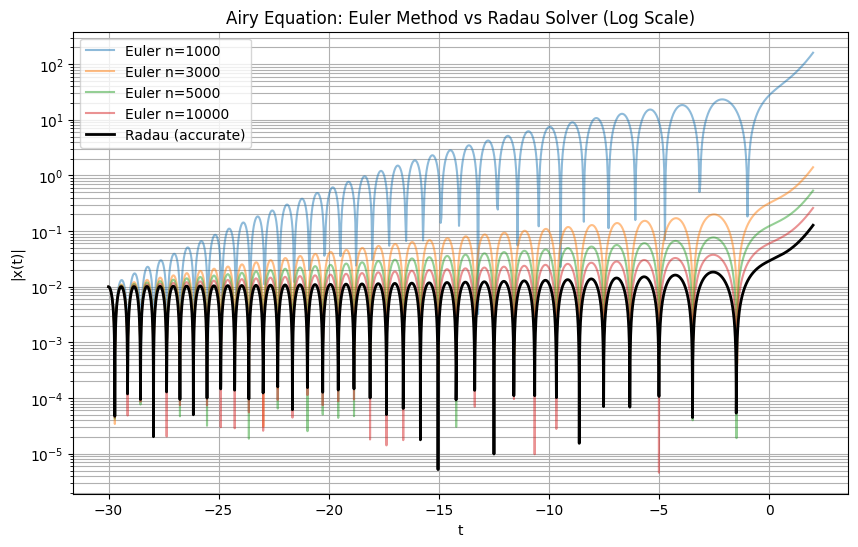

In [ ]:
plt.figure(figsize=(10, 6))

for n, (t, x_euler) in euler_solutions.items():
    plt.plot(t, np.abs(x_euler), label=f"Euler n={n}", alpha=0.5)

plt.plot(t_fine, np.abs(x_radau), "k", linewidth=2, label="Radau (accurate)")

plt.yscale("log")

plt.xlabel("t")
plt.ylabel("|x(t)|")
plt.title("Airy Equation: Euler Method vs Radau Solver (Log Scale)")
plt.legend()
plt.grid(True, which="both")
plt.show()


## Interpretation of Results: Euler Method vs Radau Solver for the Airy Equation

The plotted graph clearly demonstrates the limitations of Euler’s method when applied to the Airy equation. From the graph, we observe that at large negative values of time $t$, all Euler solutions (for different step sizes) lie close to the solution obtained using the Radau solver. In this region, the solution varies slowly, and Euler’s method is able to approximate the dynamics reasonably well. However, as time approaches $t = 0$ and becomes positive, the behavior of the solution changes significantly. The magnitude of $x(t)$ begins to grow very rapidly, and this is where the Euler method starts to fail.

The failure of Euler’s method is evident from the way the Euler trajectories separate from each other and from the Radau solution on the logarithmic scale. Solutions computed with larger step sizes smaller n diverge earlier and exhibit incorrect growth rates, while those computed with smaller step sizes follow the accurate solution slightly longer but eventually also deviate. This indicates that simply reducing the step size is not sufficient to obtain a reliable solution over the entire time interval. The fixed-step, first-order nature of Euler’s method causes local truncation errors to accumulate and get strongly amplified in regions where the solution grows rapidly.

The Airy equation is particularly well suited for illustrating this limitation because it contains a time-dependent coefficient, $t$, which makes the system increasingly unstable as time increases. For $t > 0$, the equation drives rapid growth in the solution, meaning that even very small numerical errors are magnified. As a result, numerical methods that do not adapt their step size or control error, such as Euler’s method, become unreliable. In contrast, the Radau solver automatically adjusts its step size in response to the changing behavior of the solution, allowing it to remain stable and accurate even in the rapidly growing regime.

Thus, the Airy equation serves as a clear and instructive example of why simple methods like Euler’s method are inadequate for problems with strong error amplification and varying time scales, and why more sophisticated, adaptive numerical solvers are necessary.

## Why does the behavior change specifically near \( t = 0 \)?

The point $ t = 0 $ is special in the Airy equation
$
\frac{d^2 x}{dt^2} = t\,x(t)
$
because it marks a fundamental change in the nature of the equation itself.

For $ t < 0 $, the coefficient multiplying $ x(t) $ is negative. In this region, the equation behaves like a weak restoring system, and the solutions remain bounded or grow very slowly. As a result, numerical methods such as Euler’s method can track the solution reasonably well, since errors do not get strongly amplified.

At $t = 0 $, the coefficient $t$ crosses zero. This is a **turning point** of the equation. Beyond this point $ t > 0 $, the coefficient becomes positive and increases with time, causing the equation to actively drive the solution away from zero. The system transitions from a relatively mild regime to one of rapid growth.

This change has important numerical consequences. For $ t > 0 $, any small numerical error introduced by the Euler method is no longer damped or neutral, but instead is amplified as the solution grows. Because Euler’s method uses a fixed step size and has no mechanism to control error growth, these errors accumulate rapidly once $ t $ becomes positive. This is why the Euler solutions begin to diverge from the accurate Radau solution shortly after $ t = 0 $.
